# Differential Drive Robot — System Identification

This notebook demonstrates **linear system identification** of a simplified differential drive robot using simulated data.  
The goal is to recover a discrete-time state-space model from input–output measurements, which can later be replaced with real sensor data.

---

## 1. Continuous-Time Plant Model

We model the robot with two decoupled first-order channels — **forward motion** and **turning** — each described by a DC-motor-like transfer function with time constant $\tau$ and gain $k$.

The state vector is

$$
\mathbf{x} = \begin{bmatrix} d \\ \dot{d} \\ \theta \\ \dot{\theta} \end{bmatrix},
\qquad
\mathbf{u} = \begin{bmatrix} u_{\text{fwd}} \\ u_{\text{turn}} \end{bmatrix}
$$

where $d$ is the forward distance, $\dot{d}$ the forward velocity, $\theta$ the heading angle, and $\dot{\theta}$ the angular velocity.

The continuous-time state-space matrices are

$$
A_c = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & -\frac{1}{\tau_{\text{fwd}}} & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & -\frac{1}{\tau_{\text{turn}}}
\end{bmatrix},
\qquad
B_c = \begin{bmatrix}
0 & 0 \\
\frac{k_{\text{fwd}}}{\tau_{\text{fwd}}} & 0 \\
0 & 0 \\
0 & \frac{k_{\text{turn}}}{\tau_{\text{turn}}}
\end{bmatrix}
$$

The dynamics therefore read $\dot{\mathbf{x}} = A_c\,\mathbf{x} + B_c\,\mathbf{u}$.

The model is discretised with sampling period $\Delta t$ using the exact matrix exponential:

$$
A_d = e^{A_c \Delta t}, \qquad B_d = A_c^{-1}(A_d - I)\,B_c
$$

In [16]:
import matplotlib.pyplot as plt
import AILibs
import numpy


def load_data(filepath, dt):
    raw = numpy.loadtxt(filepath)

    n = raw.shape[0]
    t_result = numpy.arange(n) * dt

    # columns 1,2 → control inputs
    u_result = raw[:, 1:3]

    # columns 3,4,5,6 → state [distance, velocity, angle, angular_rate]
    x_result = raw[:, [3, 4, 5, 6]]

    return t_result, u_result, x_result


dt = 1.0 / 250.0
t_result, u_result, x_result = load_data("data/rec_01.txt", dt)



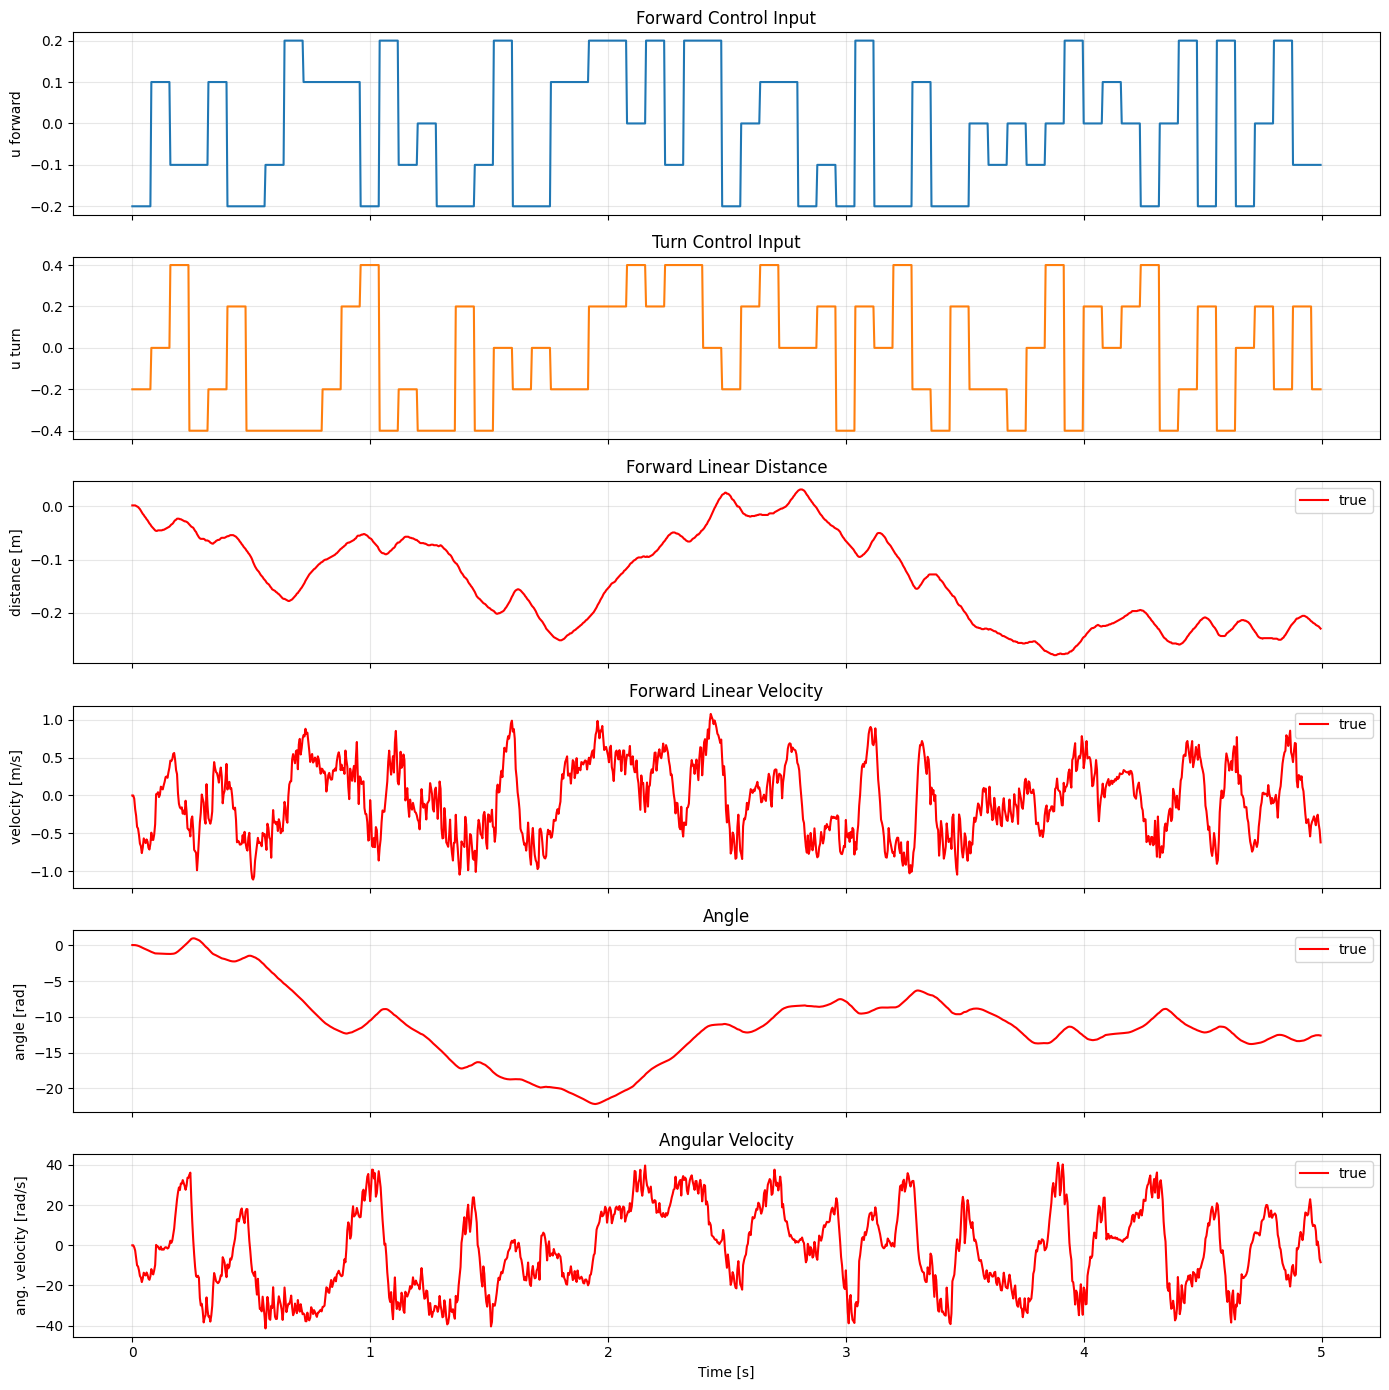

In [17]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# control input u[:, 0] - forward
axes[0].plot(t_result, u_result[:, 0], color="tab:blue")
axes[0].set_ylabel("u forward")
axes[0].set_title("Forward Control Input")
axes[0].grid(True, alpha=0.3)

# control input u[:, 1] - turn
axes[1].plot(t_result, u_result[:, 1], color="tab:orange")
axes[1].set_ylabel("u turn")
axes[1].set_title("Turn Control Input")
axes[1].grid(True, alpha=0.3)

# state x[:, 0] - forward linear distance
axes[2].plot(t_result, x_result[:, 0], label="true", color="red")
axes[2].set_ylabel("distance [m]")
axes[2].set_title("Forward Linear Distance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# state x[:, 1] - forward linear velocity
axes[3].plot(t_result, x_result[:, 1], label="true", color="red")
axes[3].set_ylabel("velocity [m/s]")
axes[3].set_title("Forward Linear Velocity")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# state x[:, 2] - angle
axes[4].plot(t_result, x_result[:, 2], label="true", color="red")
axes[4].set_ylabel("angle [rad]")
axes[4].set_title("Angle")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# state x[:, 3] - angular velocity
axes[5].plot(t_result, x_result[:, 3], label="true", color="red")
axes[5].set_ylabel("ang. velocity [rad/s]")
axes[5].set_title("Angular Velocity")
axes[5].legend()
axes[5].grid(True, alpha=0.3)

axes[5].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 3. System Identification

Given the recorded input sequence $\mathbf{u}[k]$ and noisy state observations $\hat{\mathbf{x}}[k]$, we seek discrete-time matrices $\hat{A}_d,\,\hat{B}_d$ such that

$$
\hat{\mathbf{x}}[k+1] \approx \hat{A}_d\,\hat{\mathbf{x}}[k] + \hat{B}_d\,\mathbf{u}[k]
$$

This is cast as a **linear regression** problem.  Stacking all time steps:

$$
X' = \begin{bmatrix} \hat{A}_d & \hat{B}_d \end{bmatrix} \begin{bmatrix} X \\ U \end{bmatrix}
$$

where $X'$ contains the next-step states.  Two solvers are available:

| Solver | Description |
|--------|-------------|
| **Ordinary Least Squares (OLS)** | Minimises $\|X' - \Theta Z\|_F^2$. Fast but sensitive to noise and may yield dense matrices. |
| **SR3** (Sparse Relaxed Regularised Regression) | Promotes sparsity in $\Theta$ via a relaxed $\ell_1$ penalty, recovering the known block-sparse structure of the plant. |

We compare the identified matrices against the **reference** discretised model obtained analytically via `c2d`.

In [18]:
# system identification

# Sparse Relaxed Regularized Regression — SR3 as optimizer
optimizer = AILibs.sr3_fit
#optimizer = AILibs.lr_fit

# Process identification    
A_est, B_est, _ = AILibs.system_identification(u_result, x_result, optimizer)


a_mask = numpy.array([[1.0, 1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0, 0.0],
                      [0.0, 0.0, 1.0, 1.0],
                      [0.0, 0.0, 0.0, 1.0]])


A_est*= a_mask

A_est[0, 0] = 1.0
A_est[2, 2] = 1.0


B_mask = numpy.array([[0.0, 0.0],
                      [1.0, 0.0],
                      [0.0, 0.0],
                      [0.0, 1.0]])

B_est *= B_mask


print("\nIdentified A:")
print(numpy.round(A_est, 6))


print("\nIdentified B:")
print(numpy.round(B_est, 6))

eigs = numpy.linalg.eigvals(A_est)
print("\nEigenvalues of A_est:", eigs)

A_est = numpy.array(A_est)
B_est = numpy.array(B_est)




Identified A:
[[ 1.        0.003675  0.        0.      ]
 [-0.        0.838078  0.       -0.      ]
 [ 0.       -0.        1.        0.003698]
 [ 0.       -0.       -0.        0.860136]]

Identified B:
[[ 0.        0.      ]
 [ 0.509101  0.      ]
 [ 0.        0.      ]
 [ 0.       11.300163]]

Eigenvalues of A_est: [1.        0.8380779 1.        0.8601359]


In [19]:

# ── Pole Analysis ──────────────────────────────────────────────────────────

print("\n" + "="*60)
print("POLE ANALYSIS (discrete-time, dt = {:.4f} s)".format(dt))
print("="*60)

# Stability: all poles must lie inside the unit circle
pole_magnitudes = numpy.abs(eigs)
is_stable = numpy.all(pole_magnitudes < 1.0 + 1e-10)  # tolerance for integrator poles at 1.0
is_strictly_stable = numpy.all(pole_magnitudes < 1.0 - 1e-10)

print(f"\nStability : {'STABLE' if is_stable else 'UNSTABLE'}")
print(f"Strictly stable (no poles on unit circle): {is_strictly_stable}")

# Per-pole: magnitude, continuous-time equivalent, damping, natural freq, bandwidth
print(f"\n{'Pole #':<8} {'Eigenvalue':<28} {'|z|':<10} {'s = ln(z)/dt':<30} {'ωn [rad/s]':<14} {'ζ':<10} {'BW [Hz]':<10}")
print("-" * 110)

for i, z in enumerate(eigs):
    mag = numpy.abs(z)
    # Map to continuous-time: s = ln(z) / dt
    if mag > 0:
        s = numpy.log(z + 0j) / dt
    else:
        s = float('-inf') + 0j

    sigma = s.real       # decay rate
    omega_d = s.imag     # damped frequency
    omega_n = numpy.abs(s)  # natural frequency
    zeta = -sigma / omega_n if omega_n > 1e-12 else 1.0  # damping ratio
    bw_hz = omega_n / (2.0 * numpy.pi)

    z_str = f"{z.real:+.6f}{z.imag:+.6f}j" if numpy.iscomplex(z) else f"{z.real:+.6f}"
    s_str = f"{sigma:+.4f}{omega_d:+.4f}j"

    print(f"  {i:<6} {z_str:<28} {mag:<10.6f} {s_str:<30} {omega_n:<14.4f} {zeta:<10.4f} {bw_hz:<10.4f}")

# Dominant pole (slowest non-integrator pole → smallest |ln(z)|, excluding |z|≈1 integrators)
non_integrator = [(i, z) for i, z in enumerate(eigs) if numpy.abs(numpy.abs(z) - 1.0) > 1e-6]
if non_integrator:
    dom_idx, dom_z = min(non_integrator, key=lambda p: numpy.abs(numpy.log(p[1] + 0j)))
    dom_s = numpy.log(dom_z + 0j) / dt
    dom_bw = numpy.abs(dom_s) / (2.0 * numpy.pi)
    print(f"\nDominant (slowest) non-integrator pole: #{dom_idx}  |  z = {dom_z:.6f}  |  BW ≈ {dom_bw:.4f} Hz")

# Controllability
n_states = A_est.shape[0]
ctrb = numpy.hstack([numpy.linalg.matrix_power(A_est, i) @ B_est for i in range(n_states)])
ctrb_rank = numpy.linalg.matrix_rank(ctrb)
print(f"\nControllability matrix rank: {ctrb_rank} / {n_states}  →  {'CONTROLLABLE' if ctrb_rank == n_states else 'NOT FULLY CONTROLLABLE'}")

print("="*60)


POLE ANALYSIS (discrete-time, dt = 0.0040 s)

Stability : STABLE
Strictly stable (no poles on unit circle): False

Pole #   Eigenvalue                   |z|        s = ln(z)/dt                   ωn [rad/s]     ζ          BW [Hz]   
--------------------------------------------------------------------------------------------------------------
  0      +1.000000                    1.000000   +0.0000+0.0000j                0.0000         1.0000     0.0000    
  1      +0.838078                    0.838078   -44.1611+0.0000j               44.1611        1.0000     7.0285    
  2      +1.000000                    1.000000   +0.0000+0.0000j                0.0000         1.0000     0.0000    
  3      +0.860136                    0.860136   -37.6662+0.0000j               37.6662        1.0000     5.9948    

Dominant (slowest) non-integrator pole: #3  |  z = 0.860136  |  BW ≈ 5.9948 Hz

Controllability matrix rank: 4 / 4  →  CONTROLLABLE


## 4. Model Validation — Forward Simulation

To validate the identified model we run an **open-loop forward simulation** using the identified matrices $\hat{A}_d, \hat{B}_d$ with the exact same input sequence $\mathbf{u}[k]$ and compare against the true states.

$$
\mathbf{x}_{\text{pred}}[k+1] = \hat{A}_d\,\mathbf{x}_{\text{pred}}[k] + \hat{B}_d\,\mathbf{u}[k], \qquad \mathbf{x}_{\text{pred}}[0] = \mathbf{x}[0]
$$

This is the most demanding test: any small bias in the identified matrices will **accumulate** over the full trajectory.

In [20]:
# here load the second dataset for validation
t_result, u_result, x_result = load_data("data/rec_02.txt", dt)

# Forward simulation with identified model
num_samples = len(u_result)
n_states = A_est.shape[0]

x_pred = numpy.zeros((num_samples, n_states))
x_pred[0] = x_result[0]  # start from true initial state

for k in range(num_samples - 1):
    x_pred[k + 1] = A_est @ x_pred[k] + B_est @ u_result[k]

# Prediction error
pred_error = x_result - x_pred
rmse_per_state = numpy.sqrt(numpy.mean(pred_error**2, axis=0))
state_labels = ["distance [m]", "velocity [m/s]", "angle [rad]", "ang. vel. [rad/s]"]

print("Open-loop forward simulation RMSE:")
for i, (label, rmse) in enumerate(zip(state_labels, rmse_per_state)):
    print(f"  x[{i}] ({label:20s}):  RMSE = {rmse:.6e}")

Open-loop forward simulation RMSE:
  x[0] (distance [m]        ):  RMSE = 1.220118e-02
  x[1] (velocity [m/s]      ):  RMSE = 2.020180e-01
  x[2] (angle [rad]         ):  RMSE = 3.666195e-01
  x[3] (ang. vel. [rad/s]   ):  RMSE = 5.259210e+00


done


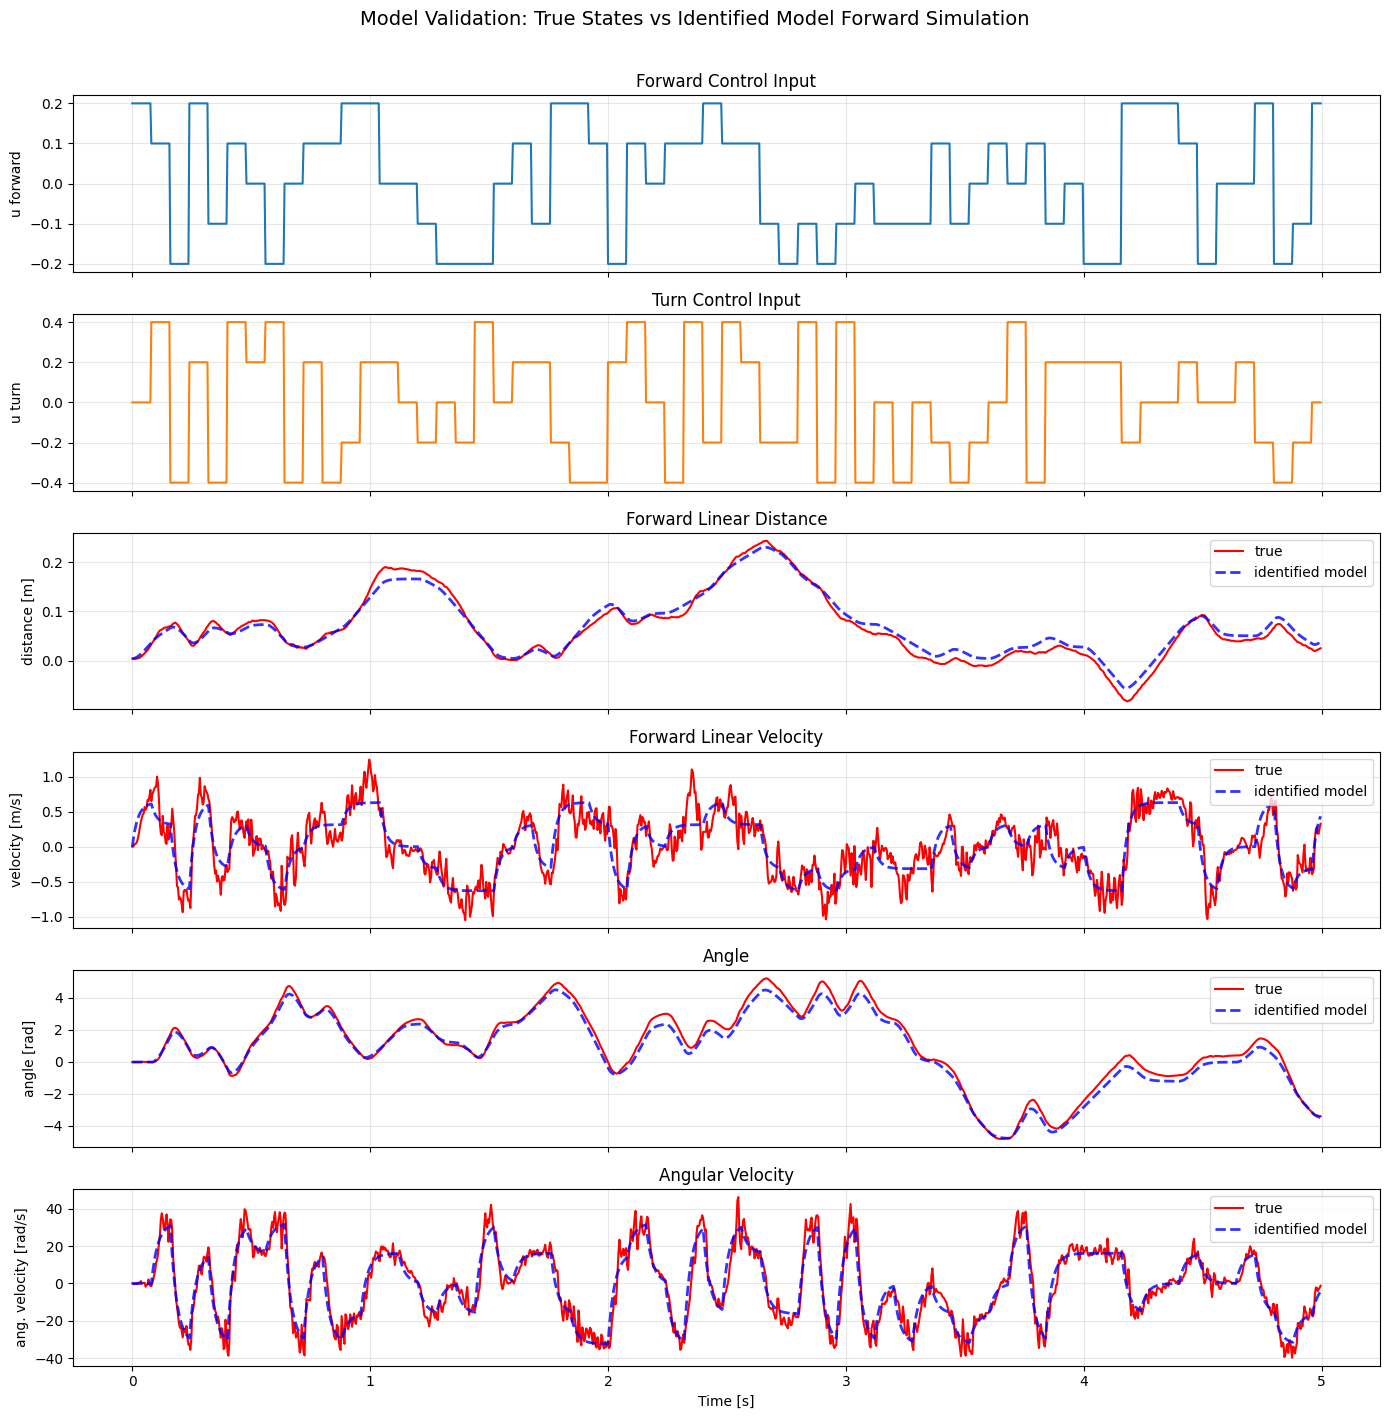

In [21]:
# Plot: true vs identified model prediction
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# control input u[:, 0] - forward
axes[0].plot(t_result, u_result[:, 0], color="tab:blue")
axes[0].set_ylabel("u forward")
axes[0].set_title("Forward Control Input")
axes[0].grid(True, alpha=0.3)

# control input u[:, 1] - turn
axes[1].plot(t_result, u_result[:, 1], color="tab:orange")
axes[1].set_ylabel("u turn")
axes[1].set_title("Turn Control Input")
axes[1].grid(True, alpha=0.3)

# state x[:, 0] - forward linear distance
axes[2].plot(t_result, x_result[:, 0], label="true", color="red")
axes[2].plot(t_result, x_pred[:, 0], label="identified model", color="blue", linestyle="--", lw=2.0, alpha=0.8)
axes[2].set_ylabel("distance [m]")
axes[2].set_title("Forward Linear Distance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# state x[:, 1] - forward linear velocity
axes[3].plot(t_result, x_result[:, 1], label="true", color="red")
axes[3].plot(t_result, x_pred[:, 1], label="identified model", color="blue", linestyle="--", lw=2.0, alpha=0.8)
axes[3].set_ylabel("velocity [m/s]")
axes[3].set_title("Forward Linear Velocity")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# state x[:, 2] - angle
axes[4].plot(t_result, x_result[:, 2], label="true", color="red")
axes[4].plot(t_result, x_pred[:, 2], label="identified model", color="blue", linestyle="--", lw=2.0, alpha=0.8)
axes[4].set_ylabel("angle [rad]")
axes[4].set_title("Angle")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# state x[:, 3] - angular velocity
axes[5].plot(t_result, x_result[:, 3], label="true", color="red")
axes[5].plot(t_result, x_pred[:, 3], label="identified model", color="blue", linestyle="--", lw=2.0, alpha=0.8)
axes[5].set_ylabel("ang. velocity [rad/s]")
axes[5].set_title("Angular Velocity")
axes[5].legend()
axes[5].grid(True, alpha=0.3)

axes[5].set_xlabel("Time [s]")

print("done")

plt.suptitle("Model Validation: True States vs Identified Model Forward Simulation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

